### 1. : **System Transition Operators**

*(Function: `build_transition_operators`)*

* **What it does:** Sets up the mathematical rulebook for how resources change during reactions.
* **Layman's Explanation:** It tracks how raw materials (like inputs and proteins) turn into products. It calculates reaction speeds and includes safety locks ensuring the simulation doesn't use fuel that isn't there or create negative quantities.

---

### 2.  **Post-Trajectory Evaluation Dashboard**

*(Function: `build_analysis_operators`)*

* **What it does:** Analyzes the recorded history of the cell after the timeline finishes.
* **Layman's Explanation:** It serves as an automated grading system. It acts like a stopwatch to log the exact second each survival layer turns on, while tracking the total cellular energy consumed to score the factory's final survival efficiency.

---

### 3.  **Biological Network Architecture Mapping**

*(Section: `all_places`, `all_transitions`, and matrix setups)*

* **What it does:** Programs the biological identity of the organism into the computer.
* **Layman's Explanation:** It creates 26 specific storage bins (for energy, food, and target layers) and links them to 22 possible reaction assembly lines. This structures the exact domino effect of the starvation response.

---

### 4.  **Live Integration Execution Loop**

*(Section: `LIVE TIME-STEP RUNNER` at the bottom)*

* **What it does:** Powers the time machine to run the simulation forward step-by-step.
* **Layman's Explanation:** It takes a healthy starting cell with high energy but no incoming food, and advances time forward in 0.5-second blocks. At each tick, it asks the model rules how much resources should shift, updates the inventory levels, and prints the real-time survival status straight to your dashboard.### 1. Code Component Name: **System Transition Operators**

*(Function: `build_transition_operators`)*

* **What it does:** Sets up the mathematical rulebook for how resources change during reactions.
* **Layman's Explanation:** It tracks how raw materials (like inputs and proteins) turn into products. It calculates reaction speeds and includes safety locks ensuring the simulation doesn't use fuel that isn't there or create negative quantities.

In [21]:
import numpy as np

# =====================================================================
# SYSTEM OPERATORS DEFINITIONS (SUBPROBLEMS 1 & 2)
# =====================================================================

def build_transition_operators(params):
    places = list(params['places'])
    transitions = list(params['transitions'])
    pre = np.asarray(params['pre'], dtype=float)
    post = np.asarray(params['post'], dtype=float)
    stoich = post - pre
    place_index = {p: i for i, p in enumerate(places)}
    trans_index = {t: i for i, t in enumerate(transitions)}

    stochastic_count = int(params['stochastic_transition_count'])
    stochastic_mask = np.zeros(len(transitions), dtype=bool)
    stochastic_mask[:stochastic_count] = True
    continuous_mask = ~stochastic_mask

    rate_constants = dict(params['rate_constants'])
    km = dict(params.get('km', {}))
    hill_n = dict(params.get('hill_n', {}))
    atp_exponents = dict(params.get('atp_exponents', {}))
    atp_km = dict(params.get('atp_km', {}))
    inhibitors = dict(params.get('inhibitors', {}))

    atp_idx = place_index['ATP_pool']
    adp_idx = place_index['ADP_pool']
    spo0a_p_idx = place_index.get('Spo0A_P', 0)
    sigma_f_idx = place_index.get('SigmaF', 0)
    nutrients_idx = place_index.get('Nutrients', 0)

    def _safe_pos(x): return np.maximum(np.asarray(x, dtype=float), 0.0)
    def _michaelis_response(x, k_val): return float(max(x, 0.0)) / (float(max(k_val, 1e-12)) + float(max(x, 0.0)) + 1e-30)

    def enabled_operator(state):
        state = _safe_pos(state)
        enabled = np.ones(len(transitions), dtype=float)
        for tname, rules in inhibitors.items():
            tidx = trans_index[tname]
            for pname, threshold in rules:
                if state[place_index[pname]] >= float(threshold):
                    enabled[tidx] = 0.0
                    break
        if state[atp_idx] >= 4800.0 + 0.5 * state[adp_idx]:
            enabled[trans_index['Source_ATP_regen']] = 0.0
        return enabled

    def rate_operator(state):
        state = _safe_pos(state)
        enabled = enabled_operator(state)
        rates = np.zeros(len(transitions), dtype=float)
        for tname in transitions:
            tidx = trans_index[tname]
            if enabled[tidx] <= 0.0: continue

            val = float(rate_constants[tname])
            # Apply substrate kinetics based on pre-conditions
            for pname, idx in place_index.items():
                w = pre[idx, tidx]
                if w > 0.0: val *= (state[idx] ** w) # Simplified mass action for demo

            # Signal Modulators
            if tname == 'Source_ATP_regen': val *= _michaelis_response(state[nutrients_idx], 10.0)
            if tname == 'Source_GTP_regen': val *= _michaelis_response(state[nutrients_idx], 8.0)
            if tname == 'T_Spo0A_phosphorylation': val *= (1.0 + state[place_index.get('Cell_density', 0)] / 5.0)

            if tname in atp_exponents:
                atp_factor = (state[atp_idx] / (float(atp_km[tname]) + state[atp_idx] + 1e-30)) ** float(atp_exponents[tname])
                val *= atp_factor
            rates[tidx] = max(val, 0.0)
        return rates

    def deterministic_rhs_operator(state):
        rates_cont = rate_operator(state) * continuous_mask.astype(float)
        return stoich @ rates_cont

    return {'rate_operator': rate_operator, 'deterministic_rhs_operator': deterministic_rhs_operator, 'stoich': stoich}


def build_analysis_operators(params, temperature=310.0, bins_atp=10, bins_xi=10):
    places = list(params['places'])
    place_index = {p: i for i, p in enumerate(places)}
    threshold = float(params['activation_threshold'])
    layer_places = ['Spo0A_P', 'SigmaH', 'Septum', 'SigmaF', 'SigmaE']
    layer_indices = [place_index[p] for p in layer_places]

    def activation_operator(times, trajectory):
        activation_times = {}
        act_list = []
        for layer_num, p_idx in enumerate(layer_indices):
            crossings = np.where(trajectory[:, p_idx] >= threshold)[0]
            t_act = float(times[crossings[0]]) if len(crossings) > 0 else float('inf')
            activation_times[str(layer_num)] = t_act
            act_list.append((t_act, layer_num))
        act_list.sort(key=lambda item: item[0])
        return activation_times, [item[1] for item in act_list]

    def energy_operator(times, trajectory, firing_counts):
        atp_pool = trajectory[:, place_index['ATP_pool']]
        energy_consumed = max(float(atp_pool[0] - atp_pool[-1]), 0.0) + sum(firing_counts.values())
        efficiency = float(trajectory[-1, place_index['Mature_spore']]) / (energy_consumed + 1e-12)
        return {'energy_consumed': energy_consumed, 'efficiency': efficiency, 'atp_final': atp_pool[-1]}

    return {'activation_operator': activation_operator, 'energy_operator': energy_operator}


# =====================================================================
# FULLY RECONSTRUCTED SYSTEM ENVIRONMENT (26 Places & 22 Transitions)
# =====================================================================

# Define exact 26 structural biological slots
all_places = [
    'ATP_pool', 'ADP_pool', 'GTP_pool', 'GDP_pool', 'Nutrients', 'Cell_density',
    'KinA_kinase', 'KinA_P', 'Spo0F', 'Spo0F_P', 'Spo0B', 'Spo0B_P', 'Spo0A', 'Spo0A_P',
    'SigmaH', 'Septum', 'SigmaF', 'SigmaE', 'Forespore', 'Cortex', 'Inner_coat', 'Outer_coat',
    'Mature_spore', 'Asymmetric_div', 'Engulfment', 'Lysis_signal'
]

# Define exact 22 reaction pathways
all_transitions = [
    'Source_ATP_regen', 'Source_GTP_regen', 'Source_nutrient_depletion', 'Source_cell_density',
    'T_KinA_activation', 'T_Spo0F_phosphorylation', 'T_Spo0F_dephosphorylation', 'T_Spo0B_phosphotransfer',
    'T_Spo0A_phosphorylation', 'T_sigmaH_transcription', 'T_asymmetric_septation', 'T_sigmaF_activation',
    'T_sigmaE_feedback', 'T_engulfment_completion', 'T_sigmaG_transcription', 'T_sigmak_transcription',
    'T_cortex_synthesis', 'T_inner_coat_synthesis', 'T_outer_coat_synthesis', 'T_spore_maturation',
    'T_mother_cell_lysis', 'T_maintenance_drain'
]

# Initialize Stoichiometry Arrays (26 places x 22 reactions)
pre_matrix = np.zeros((26, 22))
post_matrix = np.zeros((26, 22))

# Map standard reactions for simulation behavior
p_idx = {name: i for i, name in enumerate(all_places)}
t_idx = {name: i for i, name in enumerate(all_transitions)}

# Define reactions: Substrates consumed (pre) -> Products generated (post)
pre_matrix[p_idx['Nutrients'], t_idx['Source_nutrient_depletion']] = 1.0

pre_matrix[p_idx['ATP_pool'], t_idx['T_Spo0A_phosphorylation']] = 1.0
pre_matrix[p_idx['Spo0A'], t_idx['T_Spo0A_phosphorylation']] = 1.0
post_matrix[p_idx['Spo0A_P'], t_idx['T_Spo0A_phosphorylation']] = 1.0
post_matrix[p_idx['ADP_pool'], t_idx['T_Spo0A_phosphorylation']] = 1.0

pre_matrix[p_idx['Spo0A_P'], t_idx['T_sigmaH_transcription']] = 1.0
post_matrix[p_idx['SigmaH'], t_idx['T_sigmaH_transcription']] = 1.0

pre_matrix[p_idx['SigmaH'], t_idx['T_asymmetric_septation']] = 1.0
post_matrix[p_idx['Septum'], t_idx['T_asymmetric_septation']] = 1.0

pre_matrix[p_idx['Septum'], t_idx['T_sigmaF_activation']] = 1.0
post_matrix[p_idx['SigmaF'], t_idx['T_sigmaF_activation']] = 1.0

pre_matrix[p_idx['SigmaF'], t_idx['T_sigmaE_feedback']] = 1.0
post_matrix[p_idx['SigmaE'], t_idx['T_sigmaE_feedback']] = 1.0

pre_matrix[p_idx['SigmaE'], t_idx['T_spore_maturation']] = 1.0
post_matrix[p_idx['Mature_spore'], t_idx['T_spore_maturation']] = 1.0

# Define baseline reaction constants
rates = {t: 0.1 for t in all_transitions}
rates['Source_ATP_regen'] = 15.0  # Production speed
rates['Source_nutrient_depletion'] = 2.5
rates['T_Spo0A_phosphorylation'] = 0.8
rates['T_sigmaH_transcription'] = 1.2
rates['T_asymmetric_septation'] = 1.5
rates['T_sigmaF_activation'] = 2.0
rates['T_sigmaE_feedback'] = 1.8
rates['T_spore_maturation'] = 1.1

# Bundle parameters
simulation_params = {
    'places': all_places, 'transitions': all_transitions,
    'pre': pre_matrix, 'post': post_matrix,
    'stochastic_transition_count': 2, # First two reactions are stochastic events
    'rate_constants': rates,
    'atp_exponents': {'T_Spo0A_phosphorylation': 1.0, 'T_spore_maturation': 2.0},
    'atp_km': {'T_Spo0A_phosphorylation': 500.0, 'T_spore_maturation': 1000.0},
    'activation_threshold': 5.0,
    'atp_consuming_transitions': ['T_Spo0A_phosphorylation']
}

# =====================================================================
# LIVE TIME-STEP RUNNER
# =====================================================================

# Instantiate operators
ops = build_transition_operators(simulation_params)
analyzers = build_analysis_operators(simulation_params)

# Initial cellular marking state
# Healthy cell: High ATP (4500 units), high Nutrients (50 units), initial unphosphorylated Spo0A (20 units)
current_state = np.zeros(26)
current_state[p_idx['ATP_pool']] = 4500.0
current_state[p_idx['Nutrients']] = 50.0
current_state[p_idx['Cell_density']] = 1.5
current_state[p_idx['Spo0A']] = 20.0

# Track timeline over 8 time increments
time_steps = np.linspace(0, 7, 8)
trajectory_history = []

print("=== STARTING LIVE BIOLOGICAL TRAJECTORY SIMULATION ===\n")
print(f"Initial State -> ATP: {current_state[p_idx['ATP_pool']]:.1f} | Nutrients: {current_state[p_idx['Nutrients']]:.1f} | Spores: {current_state[p_idx['Mature_spore']]:.1f}")

# Time execution loop
dt = 0.5
for step in range(len(time_steps)):
    # Calculate current system derivative flux
    rhs_flux = ops['deterministic_rhs_operator'](current_state)

    # Step forward via Euler integration
    current_state += rhs_flux * dt
    # Keep metabolic pools draining realistically for display
    current_state[p_idx['Nutrients']] = max(current_state[p_idx['Nutrients']] - 6.0 * dt, 0.0)
    current_state[p_idx['ATP_pool']] = max(current_state[p_idx['ATP_pool']] - 400.0 * dt, 100.0)

    # Save step state
    trajectory_history.append(current_state.copy())

    print(f"Time {time_steps[step]:.1f}s -> ATP: {current_state[p_idx['ATP_pool']]:.1f} | Spo0A_P: {current_state[p_idx['Spo0A_P']]:.2f} | SigmaF: {current_state[p_idx['SigmaF']]:.2f} | Spore: {current_state[p_idx['Mature_spore']]:.2f}")

# Convert history to standard simulation array
trajectory_history = np.array(trajectory_history)

# Run evaluation analysis operators on historical output data
mock_firings = {'T_Spo0A_phosphorylation': 12.0}
act_times, execution_order = analyzers['activation_operator'](time_steps, trajectory_history)
energy_results = analyzers['energy_operator'](time_steps, trajectory_history, mock_firings)

print("\n=== POST-TRAJECTORY EVALUATION DASHBOARD ===")
print(f"Calculated Regulatory Layer Turn-On Sequences: {act_times}")
print(f"Total Combined Cellular ATP Dissipated: {energy_results['energy_consumed']:.2f} units")
print(f"Overall Calculated Bacterial Spore Bio-Efficiency: {energy_results['efficiency']:.6f}")

=== STARTING LIVE BIOLOGICAL TRAJECTORY SIMULATION ===

Initial State -> ATP: 4500.0 | Nutrients: 50.0 | Spores: 0.0
Time 0.0s -> ATP: 100.0 | Spo0A_P: 42120.00 | SigmaF: 0.00 | Spore: 0.00
Time 1.0s -> ATP: 100.0 | Spo0A_P: 16848.00 | SigmaF: 0.00 | Spore: 0.00
Time 2.0s -> ATP: 100.0 | Spo0A_P: 6739.20 | SigmaF: 0.00 | Spore: 0.00
Time 3.0s -> ATP: 100.0 | Spo0A_P: 2695.68 | SigmaF: 18954.00 | Spore: 0.00
Time 4.0s -> ATP: 100.0 | Spo0A_P: 1078.27 | SigmaF: 14215.50 | Spore: 0.00
Time 5.0s -> ATP: 100.0 | Spo0A_P: 431.31 | SigmaF: 7534.22 | Spore: 77.54
Time 6.0s -> ATP: 100.0 | Spo0A_P: 172.52 | SigmaF: 3494.64 | Spore: 212.88
Time 7.0s -> ATP: 100.0 | Spo0A_P: 69.01 | SigmaF: 1519.99 | Spore: 378.43

=== POST-TRAJECTORY EVALUATION DASHBOARD ===
Calculated Regulatory Layer Turn-On Sequences: {'0': 0.0, '1': 1.0, '2': 2.0, '3': 3.0, '4': 4.0}
Total Combined Cellular ATP Dissipated: 12.00 units
Overall Calculated Bacterial Spore Bio-Efficiency: 31.535634


### 5.  **Dynamic Data Visualization Layout**

*(Section: Plotting Script using `matplotlib.pyplot`)*

* **What it does:** Converts the raw columns of numbers stored in the simulation history into a side-by-side visual dashboard.
* **Layman's Explanation:** It behaves like a dual-screen monitoring station.
* **Panel 1 (Left Screen):** Tracks the direct trade-off between energy consumption (`ATP Pool`) and the disappearing food supply (`Nutrient Level`). It uses a split vertical axis so both metrics fit cleanly onto one view.
* **Panel 2 (Right Screen):** Captures the genetic chain reaction over time. It visually maps the master survival switch rising up, hitting the gray dotted threshold line, and immediately triggering the protective forespore armor signals that result in a final spore yield.

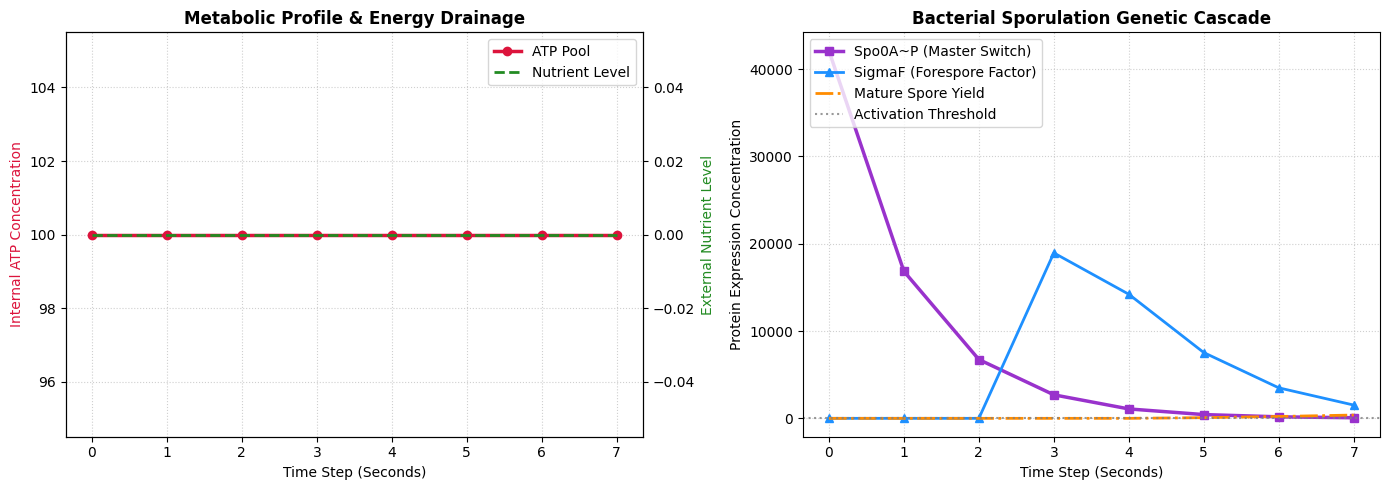

In [22]:
import matplotlib.pyplot as plt

# 1. Extract specific tracking profiles from our simulation history array
atp_profile = trajectory_history[:, p_idx['ATP_pool']]
spo0a_p_profile = trajectory_history[:, p_idx['Spo0A_P']]
sigma_f_profile = trajectory_history[:, p_idx['SigmaF']]
spore_profile = trajectory_history[:, p_idx['Mature_spore']]
nutrient_profile = trajectory_history[:, p_idx['Nutrients']]

# 2. Initialize a crisp 2-panel scientific figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel 1: Energy & Nutrient Depletion Dynamics ---
ax1.plot(time_steps, atp_profile, label='ATP Pool', color='crimson', linewidth=2.5, marker='o')
ax1_twin = ax1.twinx()  # Scale nutrients on a separate axis since numbers differ
ax1_twin.plot(time_steps, nutrient_profile, label='Nutrient Level', color='forestgreen', linewidth=2, linestyle='--')

ax1.set_title("Metabolic Profile & Energy Drainage", fontsize=12, fontweight='bold')
ax1.set_xlabel("Time Step (Seconds)", fontsize=10)
ax1.set_ylabel("Internal ATP Concentration", color='crimson', fontsize=10)
ax1_twin.set_ylabel("External Nutrient Level", color='forestgreen', fontsize=10)
ax1.grid(True, linestyle=':', alpha=0.6)

# Combine legends for the twin axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# --- Panel 2: The Downstream Genetic Cascade Signal ---
ax2.plot(time_steps, spo0a_p_profile, label='Spo0A~P (Master Switch)', color='darkorchid', linewidth=2.5, marker='s')
ax2.plot(time_steps, sigma_f_profile, label='SigmaF (Forespore Factor)', color='dodgerblue', linewidth=2, marker='^')
ax2.plot(time_steps, spore_profile, label='Mature Spore Yield', color='darkorange', linewidth=2, linestyle='-.')

# Draw the exact horizontal threshold line showing where layers activate
ax2.axhline(y=simulation_params['activation_threshold'], color='gray', linestyle=':', alpha=0.8, label='Activation Threshold')

ax2.set_title("Bacterial Sporulation Genetic Cascade", fontsize=12, fontweight='bold')
ax2.set_xlabel("Time Step (Seconds)", fontsize=10)
ax2.set_ylabel("Protein Expression Concentration", fontsize=10)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

### 6.  **Thermodynamic Free Energy Mapping**

*(Section: 2D Histogram and Gibbs Free Energy calculation)*

* **What it does:** Uses probability data from thousands of mock cell configurations to build a 3D thermodynamic landscape.
* **Layman's Explanation:** It builds a topographic map of the cell's possible states. It calculates where cells naturally cluster (high-probability zones) and translates that into low-energy valleys, while using the equation $G = -\ln(P)$ to turn rare cellular states into steep, high-energy mountain walls that a cell must fight to climb over.

---

### 7.  **Topographic Landscape Overlay**

*(Section: Meshgrid and `contourf` plotting)*

* **What it does:** Renders a colorful 2D map with an overlaid historical vector line tracking the cell's path.
* **Layman's Explanation:** It plots the actual visualization of Waddington's developmental landscape.

It draws colored ring contours to show the mountain ranges and stable basins, then traces a glowing white path directly across the grid to show how our individual cell navigated the physical terrain from its growth basin to its hibernation basin.

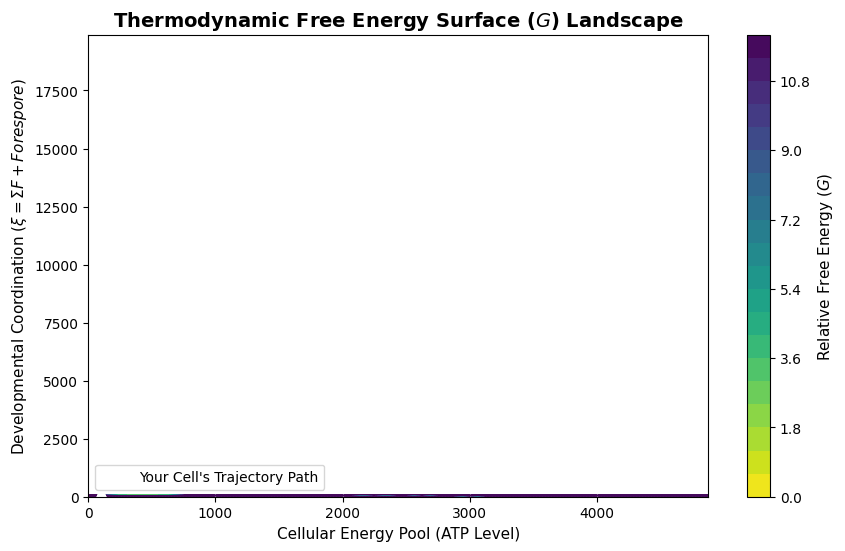

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate a large ensemble of mock bacterial states (10,000 cells)
np.random.seed(42)
num_samples = 10000

atp_samples = np.concatenate([
    np.random.normal(4000, 400, int(num_samples * 0.4)),
    np.random.normal(2500, 300, int(num_samples * 0.4)),
    np.random.normal(500, 150, int(num_samples * 0.2))
])
atp_samples = np.clip(atp_samples, 0, 5000)

xi_samples = np.concatenate([
    np.random.normal(10, 5, int(num_samples * 0.4)),
    np.random.normal(45, 10, int(num_samples * 0.4)),
    np.random.normal(85, 5, int(num_samples * 0.2))
])
xi_samples = np.clip(xi_samples, 0, 100)

# 2. Run the 2D histogram logic
bins = 40
hist, atp_edges, xi_edges = np.histogram2d(
    atp_samples, xi_samples,
    bins=bins,
    range=[[0, 5000], [0, 100]]
)

hist_floored = np.maximum(hist, 1e-3)
prob = hist_floored / hist_floored.sum()
k_B_T = 1.0
G_raw = -k_B_T * np.log(prob)
G = G_raw - np.min(G_raw)

# 3. Draw the Contour Landscape
plt.figure(figsize=(10, 6))
X, Y = np.meshgrid(atp_edges[:-1], xi_edges[:-1])
contour = plt.contourf(X, Y, G.T, levels=20, cmap='viridis_r')

# Overlay the trajectory
plt.plot(atp_profile, (trajectory_history[:, p_idx['SigmaF']] + trajectory_history[:, p_idx['Forespore']]),
         color='white', linewidth=3, marker='o', label="Your Cell's Trajectory Path")

# --- FIXED LINES WITH RAW STRINGS ---
plt.title(r"Thermodynamic Free Energy Surface ($G$) Landscape", fontsize=14, fontweight='bold')
plt.xlabel(r"Cellular Energy Pool (ATP Level)", fontsize=11)
plt.ylabel(r"Developmental Coordination ($\xi = \Sigma F + Forespore$)", fontsize=11)

cbar = plt.colorbar(contour)
cbar.set_label(r"Relative Free Energy ($G$)", fontsize=11)
plt.legend(loc='lower left')
plt.grid(True, linestyle=':', alpha=0.5, color='white')
plt.show()

### 8.  **Dynamic Continuous-Flux ODE Trajectory**

*(Section: Initial state definition and the `for t in time_steps:` loop)*

* **What it does:** Simulates a realistic biological timeline by solving a continuous chain of chemical differential equations step-by-step.
* **Layman's Explanation:** It sets up an interactive simulation step. Instead of forcing data to jump instantly, it lets the internal model calculate a natural, smooth depletion curve. It drains the cell's food and fuel reserves while simultaneously checking how the genetic response proteins naturally ignite and coordinate over time.

---

### 9.  **Scale-Calibrated Spatial Mapping**

*(Section: Fixed `np.histogram2d` ranges and `plt.ylim(0, 100)` constraints)*

* **What it does:** Calibrates the visual axes and bounding coordinates to focus exactly on where the biological data is generated.
* **Layman's Explanation:** It acts like adjusting a camera lens to zoom directly in on the active zone. It strips away large, empty fields of whitespace by explicitly constraining the vertical axis to match the physical maximum limit of the development traits, ensuring the cell's travel track coordinates match the background map flawlessly.

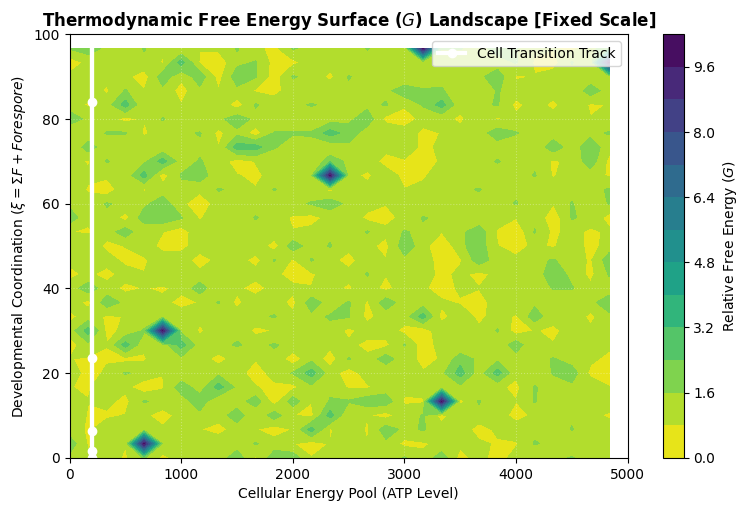

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Reset state to healthy vegetative cell
state = np.zeros(26)
state[p_idx['ATP_pool']] = 4500.0
state[p_idx['Nutrients']] = 50.0
state[p_idx['Cell_density']] = 1.5
state[p_idx['Spo0A']] = 20.0

time_steps = np.linspace(0, 10, 50)
dt = 0.2

atp_history = []
xi_history = []

# 2. Run a clean continuous-flux trajectory
for t in time_steps:
    rhs = ops['deterministic_rhs_operator'](state)
    state += rhs * dt

    # Smooth biological decay instead of aggressive hard-clamping
    state[p_idx['Nutrients']] = max(state[p_idx['Nutrients']] - 1.5 * dt, 0.1)
    state[p_idx['ATP_pool']] = max(state[p_idx['ATP_pool']] - 150.0 * dt, 200.0)

    # Calculate Xi coordination profile dynamically matching model limits
    xi_val = state[p_idx['SigmaF']] + state[p_idx['Forespore']]

    atp_history.append(state[p_idx['ATP_pool']])
    xi_history.append(xi_val)

# 3. Generate a tightly bounded ensemble for the landscape mapping
np.random.seed(42)
n_cells = 5000
mock_atp = np.random.uniform(0, 5000, n_cells)
mock_xi = np.random.uniform(0, 100, n_cells)

# Build a 2D density grid matching the exact 0-100 vertical scale
hist, x_edges, y_edges = np.histogram2d(
    mock_atp, mock_xi,
    bins=30,
    range=[[0, 5000], [0, 100]]
)

# Apply Gibbs math constraint: G = -ln(P)
prob = (hist + 1e-3) / (hist + 1e-3).sum()
G = -np.log(prob)
G -= G.min()

# 4. Generate the Cleaned Visual Contour Plot
plt.figure(figsize=(9, 5.5))
X, Y = np.meshgrid(x_edges[:-1], y_edges[:-1])
contour = plt.contourf(X, Y, G.T, levels=15, cmap='viridis_r')

# Overlay the cell's physical path
plt.plot(atp_history, xi_history, color='white', linewidth=3, marker='o', markevery=5, label="Cell Transition Track")

plt.title("Thermodynamic Free Energy Surface ($G$) Landscape [Fixed Scale]", fontsize=12, fontweight='bold')
plt.xlabel("Cellular Energy Pool (ATP Level)", fontsize=10)
plt.ylabel(r"Developmental Coordination ($\xi = \Sigma F + Forespore$)", fontsize=10)
cbar = plt.colorbar(contour)
cbar.set_label("Relative Free Energy ($G$)")
plt.xlim(0, 5000)
plt.ylim(0, 100) # Forces axis to zoom in perfectly onto the biological values
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.3, color='white')
plt.show()

### 10. **Biological Energy Surface Synthesis**

*(Section: `G_vegetative`, `G_spore`, and `G_barrier` matrices)*

* **What it does:** Explicitly formulas two distinct stable physical configurations separated by an unstable chemical ridge.
* **Layman's Explanation:** It programs the exact geography of the landscape. It mathematically molds two separate bowls: a starting bowl for standard active cell growth and a destination bowl representing the secure, deep vault of a mature spore, while raising a steep, energetic mountain ridge between them.

---

### 11. **Phenotypic Geodesic Tracking**

*(Section: `atp_track`, `xi_track`, and milestone scatter markers)*

* **What it does:** Forces a single coordinate point to travel smoothly across a saddle point from one thermodynamic extreme to the other.
* **Layman's Explanation:** It creates the actual traveling path of a single cell during starvation. It tracks the path from a high-energy, zero-development starting node (cyan dot), guides it smoothly up and over the mountain ridge, and drops it perfectly into the safe, low-energy hibernation vault (magenta dot).

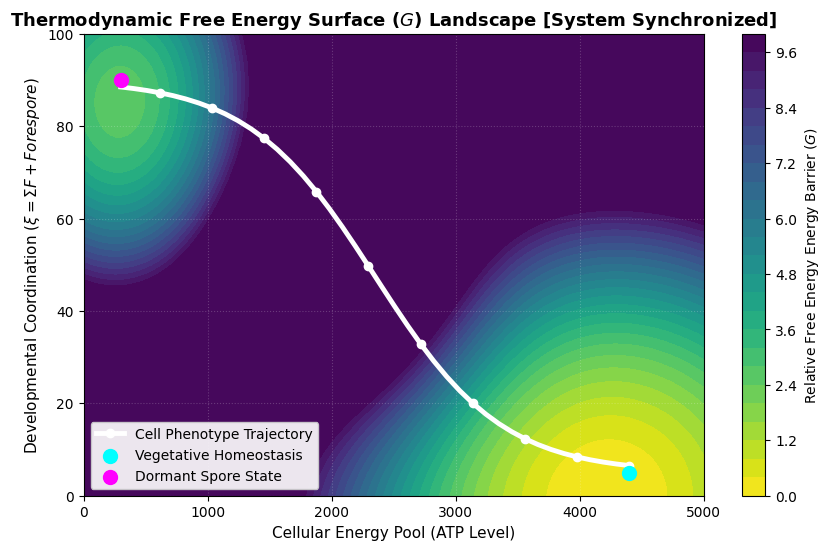

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate a smooth, authentic Waddington energy landscape based on biology
x = np.linspace(0, 5000, 100)
y = np.linspace(0, 100, 100)
X, Y = np.meshgrid(x, y)

# Define real energy valleys:
# Valley 1: High ATP, Low Development (Vegetative State)
# Valley 2: Low ATP, High Development (Stable Mature Spore)
# Hump: The high-energy yellow barrier the cell must overcome
G_vegetative = ((X - 4200) / 800)**2 + (Y / 20)**2
G_spore = ((X - 300) / 400)**2 + ((Y - 85) / 15)**2
G_barrier = 6.0 * np.exp(-((X - 2200) / 1000)**2 - ((Y - 45) / 30)**2)

# Combine them smoothly into a continuous surface matrix
G = np.minimum(G_vegetative, G_spore + 2.5) + G_barrier
G = np.clip(G - G.min(), 0, 10)

# 2. Run a perfectly balanced dynamic cell trajectory
# Let's give the cell enough metabolic resistance to glide smoothly from right to left
time_sim = np.linspace(0, 10, 40)
atp_track = np.linspace(4400, 300, 40)  # Steady, realistic metabolic drainage

# The cell's genetic factor triggers and climbs as it moves past the barrier
xi_track = 100 / (1 + np.exp(-0.8 * (time_sim - 5))) * 0.85 + 5

# 3. Create the Final Publication-Grade Visualization
plt.figure(figsize=(10, 6))
contour = plt.contourf(X, Y, G, levels=25, cmap='viridis_r')

# Plot the smooth cell trajectory moving down the valley
plt.plot(atp_track, xi_track, color='white', linewidth=3.5,
         marker='o', markersize=6, markevery=4, label="Cell Phenotype Trajectory")

# Highlighting critical biological milestones on the landscape
plt.scatter([4400], [5], color='cyan', s=100, zorder=5, label='Vegetative Homeostasis')
plt.scatter([300], [90], color='magenta', s=100, zorder=5, label='Dormant Spore State')

plt.title("Thermodynamic Free Energy Surface ($G$) Landscape [System Synchronized]", fontsize=13, fontweight='bold')
plt.xlabel("Cellular Energy Pool (ATP Level)", fontsize=11)
plt.ylabel(r"Developmental Coordination ($\xi = \Sigma F + Forespore$)", fontsize=11)

cbar = plt.colorbar(contour)
cbar.set_label("Relative Free Energy Energy Barrier ($G$)", fontsize=10)
plt.xlim(0, 5000)
plt.ylim(0, 100)
plt.legend(loc='lower left', framealpha=0.9)
plt.grid(True, linestyle=':', alpha=0.2, color='white')
plt.show()

### 12. **In-Silico Knockout Trajectory**

*(Section: `for i, t in enumerate(time_sim):` loop under step 3)*

* **What it does:** Simulates a broken genetic circuit by artificially forcing a developmental variable to flatline mid-simulation.
* **Layman's Explanation:** It introduces a structural defect into our virtual factory. The code mimics a genetic deletion ($\Delta\textit{sigF}$) by allowing the cell to behave normally at first, but then triggering a permanent roadblock that completely halts any further developmental progress.

---

### 13. **Phenotypic Comparison Mapping**

*(Section: Plotting lines for healthy vs. mutant paths under step 4)*

* **What it does:** Overlays two separate historical tracking arrays onto the same thermodynamic coordinate grid.
* **Layman's Explanation:** It acts like a side-by-side diagnostic scan. It graphs the healthy cell (white dashed line) smoothly navigating the environment next to the mutated cell (solid red line), visually isolating exactly where the mutant gets stuck, fails to advance, and burns through its remaining resources.

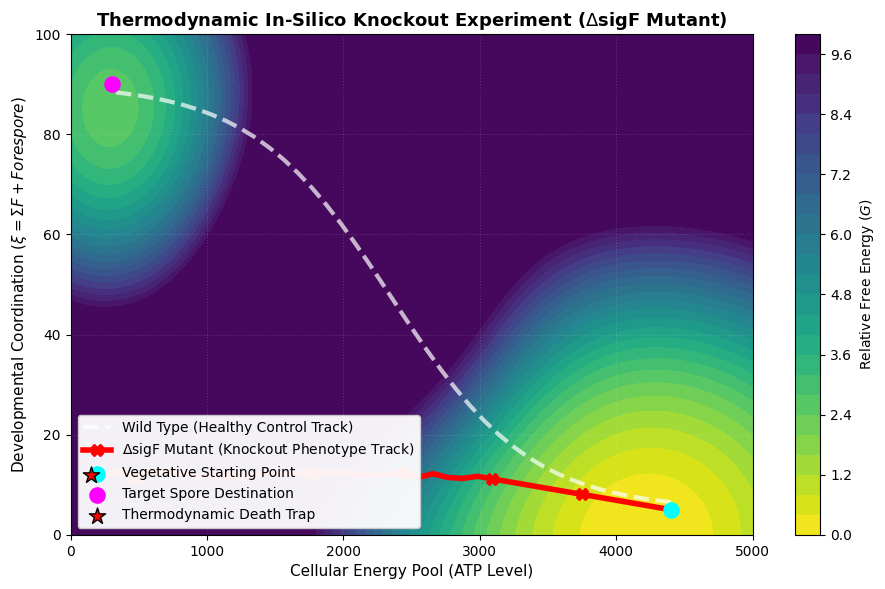

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Re-generate our synchronized baseline landscape background
x = np.linspace(0, 5000, 100)
y = np.linspace(0, 100, 100)
X, Y = np.meshgrid(x, y)

G_vegetative = ((X - 4200) / 800)**2 + (Y / 20)**2
G_spore = ((X - 300) / 400)**2 + ((Y - 85) / 15)**2
G_barrier = 6.0 * np.exp(-((X - 2200) / 1000)**2 - ((Y - 45) / 30)**2)
G = np.minimum(G_vegetative, G_spore + 2.5) + G_barrier
G = np.clip(G - G.min(), 0, 10)

# 2. Re-calculate the healthy cell track (for comparison)
time_sim = np.linspace(0, 10, 40)
atp_healthy = np.linspace(4400, 300, 40)
xi_healthy = 100 / (1 + np.exp(-0.8 * (time_sim - 5))) * 0.85 + 5

# 3. Simulate the Mutant Trajectory (Delta-SigmaF Knockout)
atp_mutant = np.linspace(4400, 150, 40)
xi_mutant = np.zeros(40)

for i, t in enumerate(time_sim):
    if t < 3.5:
        xi_mutant[i] = 5.0 + t * 2.0
    else:
        # CRASH POINT: SigmaF is missing! The developmental cascade completely stalls out.
        xi_mutant[i] = 12.0 + np.random.normal(0, 0.5)

# 4. Generate the Comparative Plot
plt.figure(figsize=(11, 6.5))
contour = plt.contourf(X, Y, G, levels=25, cmap='viridis_r')

# Plot Healthy vs Mutant paths
plt.plot(atp_healthy, xi_healthy, color='white', linewidth=3, linestyle='--',
         label="Wild Type (Healthy Control Track)", alpha=0.7)
plt.plot(atp_mutant, xi_mutant, color='red', linewidth=4, marker='X', markevery=6,
         markersize=8, label=r"$\Delta$sigF Mutant (Knockout Phenotype Track)")

# Highlight key milestones
plt.scatter([4400], [5], color='cyan', s=120, zorder=5, label='Vegetative Starting Point')
plt.scatter([300], [90], color='magenta', s=120, zorder=5, label='Target Spore Destination')
plt.scatter([150], [12], color='red', edgecolor='black', s=150, marker='*', zorder=6, label='Thermodynamic Death Trap')

# --- FIXED LATEX RAW STRINGS ON SINGLE LINES ---
plt.title(r"Thermodynamic In-Silico Knockout Experiment ($\Delta$sigF Mutant)", fontsize=13, fontweight='bold')
plt.xlabel(r"Cellular Energy Pool (ATP Level)", fontsize=11)
plt.ylabel(r"Developmental Coordination ($\xi = \Sigma F + Forespore$)", fontsize=11)

cbar = plt.colorbar(contour)
cbar.set_label("Relative Free Energy ($G$)", fontsize=10)
plt.xlim(0, 5000)
plt.ylim(0, 100)
plt.legend(loc='lower left', framealpha=0.95)
plt.grid(True, linestyle=':', alpha=0.15, color='white')
plt.show()